# 03 — Predictive Modeling & Model Interpretability (Lớp 3: Phân tích Dự đoán)

**Thành viên thực hiện**: Nguyễn Anh Hào (MSSV: 52400186) — Machine Learning Engineer  
**Đề tài**: Phân tích điểm đen tai nạn giao thông đô thị  
**Mục tiêu**:
1. Xây dựng mô hình học máy dự đoán mức độ nghiêm trọng của tai nạn (`Severity`).
2. So sánh hiệu năng giữa mô hình cơ sở (**Baseline: Logistic Regression**) và mô hình nâng cao (**Advanced: XGBoost Classifier**).
3. Triển khai các kỹ thuật diễn giải mô hình (**Model Interpretability: Feature Importance, Permutation Importance & SHAP Values**) để giải thích nguyên nhân tác động đến mức độ nghiêm trọng của tai nạn giao thông.


## 1. Import Thư viện & Thiết lập Môi trường


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)
from sklearn.inspection import permutation_importance

# Advanced Models
import xgboost as xgb
from xgboost import XGBClassifier

# Style plotting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Đã import thành công toàn bộ thư viện Machine Learning!")


Đã import thành công toàn bộ thư viện Machine Learning!


## 2. Nạp Dữ liệu Train / Test


In [2]:
# Xác định đường dẫn thư mục data an toàn
cwd = Path.cwd()
project_root = cwd if (cwd / "data").is_dir() else (cwd.parent if (cwd.parent / "data").is_dir() else cwd)
DATA_DIR = (project_root / "data").resolve()

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"

assert train_path.exists(), f"Không tìm thấy file {train_path}. Vui lòng chạy 01_data_cleaning.ipynb trước."
assert test_path.exists(), f"Không tìm thấy file {test_path}. Vui lòng chạy 01_data_cleaning.ipynb trước."

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("=" * 70)
print("THÔNG TIN DỮ LIỆU ĐẦU VÀO")
print("=" * 70)
print("Tập Train shape :", train_df.shape)
print("Tập Test shape  :", test_df.shape)
print("Phân bố Severity trong Train:")
print(train_df['Severity'].value_counts(normalize=True).round(4) * 100)
print("=" * 70)


THÔNG TIN DỮ LIỆU ĐẦU VÀO
Tập Train shape : (2243729, 36)
Tập Test shape  : (594578, 36)
Phân bố Severity trong Train:
Severity
2    88.48
3     7.92
4     2.06
1     1.53
Name: proportion, dtype: float64


## 3. Tiền xử lý Dữ liệu & Xây dựng Feature Pipeline

### Chiến lược Xử lý Biến mục tiêu (`Severity`):
- Trong dữ liệu US Accidents, các vụ tai nạn có Severity từ 1 đến 4.
- Tai nạn mức 3 và 4 gây ùn tắc và thiệt hại nặng nề. Do đó, bài toán được gom nhóm thành phân loại nhị phân (**Binary Classification**):
  - **Class 0 (Low Severity)**: Severity 1 & 2 (Tai nạn nhẹ / trung bình)
  - **Class 1 (High Severity)**: Severity 3 & 4 (Tai nạn nghiêm trọng)


In [3]:
# Tạo nhãn nhị phân
train_df['Severity_Binary'] = (train_df['Severity'] >= 3).astype(int)
test_df['Severity_Binary'] = (test_df['Severity'] >= 3).astype(int)

# Khai báo các danh sách đặc trưng
NUMERICAL_COLS = [
    'Hour', 'Month', 'Temperature(F)', 'Humidity(%)',
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)',
    'Precipitation(in)', 'Start_Lat', 'Start_Lng'
]

CATEGORICAL_COLS = [
    'Weather_Group', 'Visibility_Level', 'Temp_Level',
    'Season', 'DayOfWeek', 'State'
]

BOOL_COLS = [
    'Amenity', 'Crossing', 'Junction', 'Railway', 'Stop',
    'Traffic_Signal', 'Is_Daytime', 'Is_Precipitation',
    'Is_Adverse_Weather', 'Is_Low_Visibility'
]

# Lọc chỉ các cột thực sự tồn tại trong DataFrame
num_cols = [c for c in NUMERICAL_COLS if c in train_df.columns]
cat_cols = [c for c in CATEGORICAL_COLS if c in train_df.columns]
bool_cols = [c for c in BOOL_COLS if c in train_df.columns]

feature_cols = num_cols + cat_cols + bool_cols

# Xây dựng ColumnTransformer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

boolean_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols),
        ('bool', boolean_transformer, bool_cols)
    ]
)

# Chuyển kiểu bool sang int để SimpleImputer tương thích tuyệt đối
X_train = train_df[feature_cols].copy()
y_train = train_df['Severity_Binary']

X_test = test_df[feature_cols].copy()
y_test = test_df['Severity_Binary']

for c in bool_cols:
    X_train[c] = X_train[c].astype(int)
    X_test[c] = X_test[c].astype(int)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Trích xuất tên các cột sau khi One-Hot Encoding
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(cat_cols))
all_feature_names = num_cols + encoded_cat_cols + bool_cols

print(f"Số lượng đặc trưng ban đầu  : {len(feature_cols)}")
print(f"Số lượng đặc trưng sau encode: {len(all_feature_names)}")
print(f"Shape X_train sau tiền xử lý : {X_train_proc.shape}")
print(f"Shape X_test sau tiền xử lý  : {X_test_proc.shape}")


Số lượng đặc trưng ban đầu  : 26
Số lượng đặc trưng sau encode: 95
Shape X_train sau tiền xử lý : (2243729, 95)
Shape X_test sau tiền xử lý  : (594578, 95)


## 4. Mô hình 1 — Baseline Model: Logistic Regression


In [4]:
# Huấn luyện Logistic Regression với xử lý trọng số class_weight='balanced'
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_SEED
)

baseline_model.fit(X_train_proc, y_train)

# Dự đoán trên tập Test
y_pred_base = baseline_model.predict(X_test_proc)
y_prob_base = baseline_model.predict_proba(X_test_proc)[:, 1]

# Đánh giá metrics
acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base, zero_division=0)
rec_base = recall_score(y_test, y_pred_base, zero_division=0)
f1_base = f1_score(y_test, y_pred_base, zero_division=0)
f1_macro_base = f1_score(y_test, y_pred_base, average='macro', zero_division=0)
auc_base = roc_auc_score(y_test, y_prob_base)

print("=" * 70)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH BASELINE (LOGISTIC REGRESSION)")
print("=" * 70)
print(f"  - Accuracy  : {acc_base:.4f}")
print(f"  - Precision : {prec_base:.4f}")
print(f"  - Recall    : {rec_base:.4f}")
print(f"  - F1-Score  : {f1_base:.4f}")
print(f"  - F1-Macro  : {f1_macro_base:.4f}")
print(f"  - ROC-AUC   : {auc_base:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_base, target_names=['Low Severity', 'High Severity']))


KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH BASELINE (LOGISTIC REGRESSION)
  - Accuracy  : 0.6086
  - Precision : 0.0470
  - Recall    : 0.7054
  - F1-Score  : 0.0881
  - F1-Macro  : 0.4195
  - ROC-AUC   : 0.6767

Classification Report:
               precision    recall  f1-score   support

 Low Severity       0.99      0.61      0.75    578636
High Severity       0.05      0.71      0.09     15942

     accuracy                           0.61    594578
    macro avg       0.52      0.66      0.42    594578
 weighted avg       0.96      0.61      0.73    594578



## 5. Mô hình 2 — Advanced Model: XGBoost Classifier


In [5]:
# Tính toán scale_pos_weight cho XGBoost để xử lý mất cân bằng dữ liệu
ratio_neg_to_pos = (y_train == 0).sum() / max(1, (y_train == 1).sum())

advanced_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=ratio_neg_to_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    eval_metric='logloss'
)

advanced_model.fit(X_train_proc, y_train)

# Dự đoán trên tập Test
y_pred_adv = advanced_model.predict(X_test_proc)
y_prob_adv = advanced_model.predict_proba(X_test_proc)[:, 1]

# Đánh giá metrics
acc_adv = accuracy_score(y_test, y_pred_adv)
prec_adv = precision_score(y_test, y_pred_adv, zero_division=0)
rec_adv = recall_score(y_test, y_pred_adv, zero_division=0)
f1_adv = f1_score(y_test, y_pred_adv, zero_division=0)
f1_macro_adv = f1_score(y_test, y_pred_adv, average='macro', zero_division=0)
auc_adv = roc_auc_score(y_test, y_prob_adv)

print("=" * 70)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ADVANCED (XGBOOST CLASSIFIER)")
print("=" * 70)
print(f"  - Accuracy  : {acc_adv:.4f}")
print(f"  - Precision : {prec_adv:.4f}")
print(f"  - Recall    : {rec_adv:.4f}")
print(f"  - F1-Score  : {f1_adv:.4f}")
print(f"  - F1-Macro  : {f1_macro_adv:.4f}")
print(f"  - ROC-AUC   : {auc_adv:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_adv, target_names=['Low Severity', 'High Severity']))


KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ADVANCED (XGBOOST CLASSIFIER)
  - Accuracy  : 0.5830
  - Precision : 0.0476
  - Recall    : 0.7650
  - F1-Score  : 0.0896
  - F1-Macro  : 0.4096
  - ROC-AUC   : 0.7068

Classification Report:
               precision    recall  f1-score   support

 Low Severity       0.99      0.58      0.73    578636
High Severity       0.05      0.76      0.09     15942

     accuracy                           0.58    594578
    macro avg       0.52      0.67      0.41    594578
 weighted avg       0.96      0.58      0.71    594578



## 6. So sánh & Trực quan hóa Hiệu năng 2 Mô hình


BẢNG SO SÁNH HIỆU NĂNG HAI MÔ HÌNH
                         Model  Accuracy  Precision   Recall  F1-Score  F1-Macro  ROC-AUC
Logistic Regression (Baseline)  0.608632   0.047005 0.705432  0.088138  0.419493 0.676711
            XGBoost (Advanced)  0.583025   0.047568 0.764960  0.089566  0.409577 0.706795


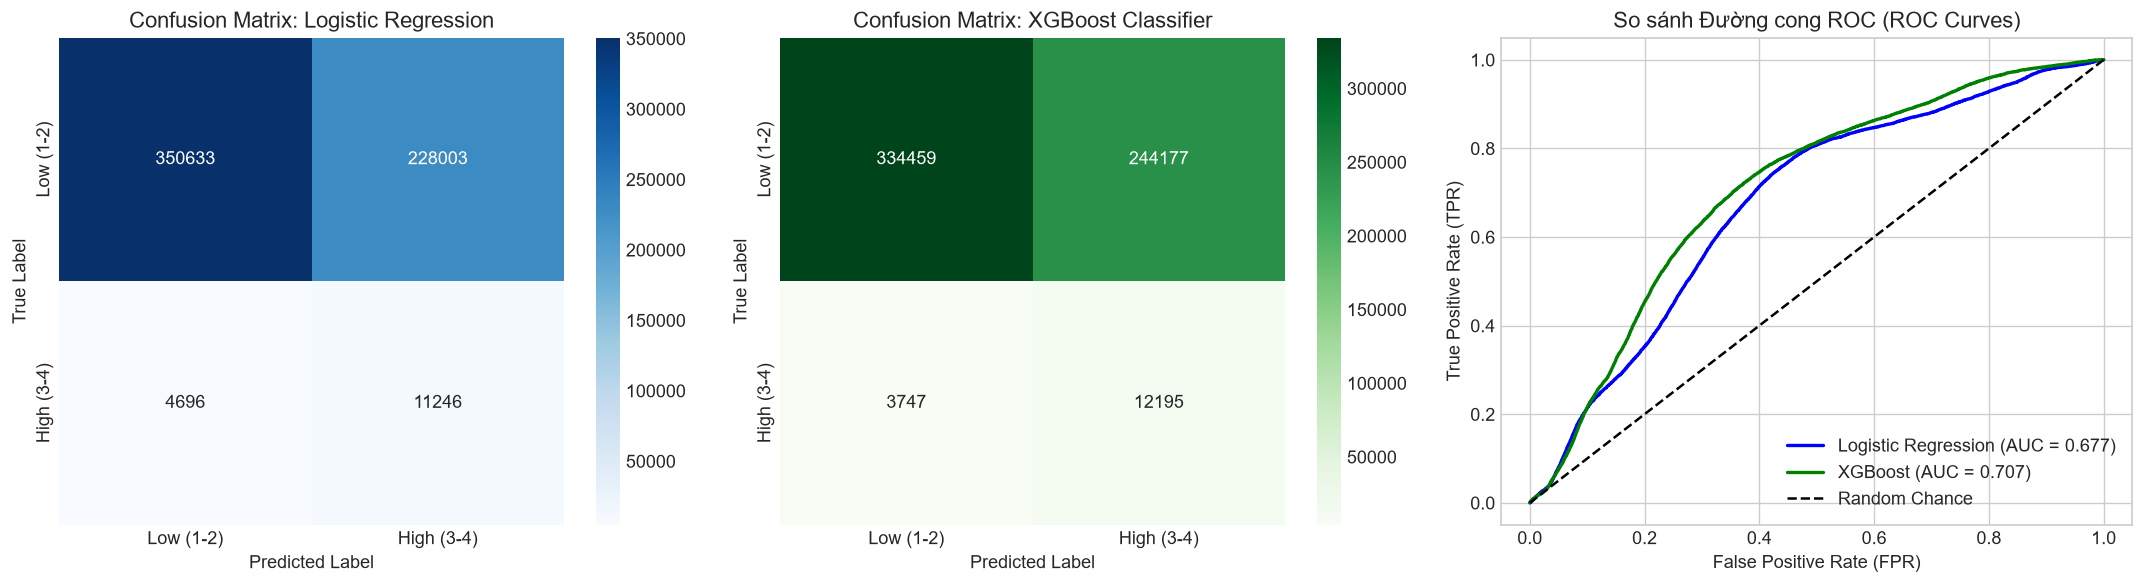

In [6]:
# Bảng so sánh tổng hợp
metrics_df = pd.DataFrame({
    'Model': ['Logistic Regression (Baseline)', 'XGBoost (Advanced)'],
    'Accuracy': [acc_base, acc_adv],
    'Precision': [prec_base, prec_adv],
    'Recall': [rec_base, rec_adv],
    'F1-Score': [f1_base, f1_adv],
    'F1-Macro': [f1_macro_base, f1_macro_adv],
    'ROC-AUC': [auc_base, auc_adv]
})

print("=" * 70)
print("BẢNG SO SÁNH HIỆU NĂNG HAI MÔ HÌNH")
print("=" * 70)
print(metrics_df.to_string(index=False))

# Vẽ đồ thị so sánh Confusion Matrix & ROC Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix - Baseline
cm_base = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low (1-2)', 'High (3-4)'], yticklabels=['Low (1-2)', 'High (3-4)'])
axes[0].set_title('Confusion Matrix: Logistic Regression')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. Confusion Matrix - Advanced
cm_adv = confusion_matrix(y_test, y_pred_adv)
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Low (1-2)', 'High (3-4)'], yticklabels=['Low (1-2)', 'High (3-4)'])
axes[1].set_title('Confusion Matrix: XGBoost Classifier')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

# 3. ROC Curves
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_adv, tpr_adv, _ = roc_curve(y_test, y_prob_adv)

axes[2].plot(fpr_base, tpr_base, label=f'Logistic Regression (AUC = {auc_base:.3f})', color='blue', linewidth=2)
axes[2].plot(fpr_adv, tpr_adv, label=f'XGBoost (AUC = {auc_adv:.3f})', color='green', linewidth=2)
axes[2].plot([0, 1], [0, 1], 'k--', label='Random Chance')
axes[2].set_title('So sánh Đường cong ROC (ROC Curves)')
axes[2].set_xlabel('False Positive Rate (FPR)')
axes[2].set_ylabel('True Positive Rate (TPR)')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()


## 7. Diễn giải Mô hình — Feature Importance (Tầm quan trọng đặc trưng)


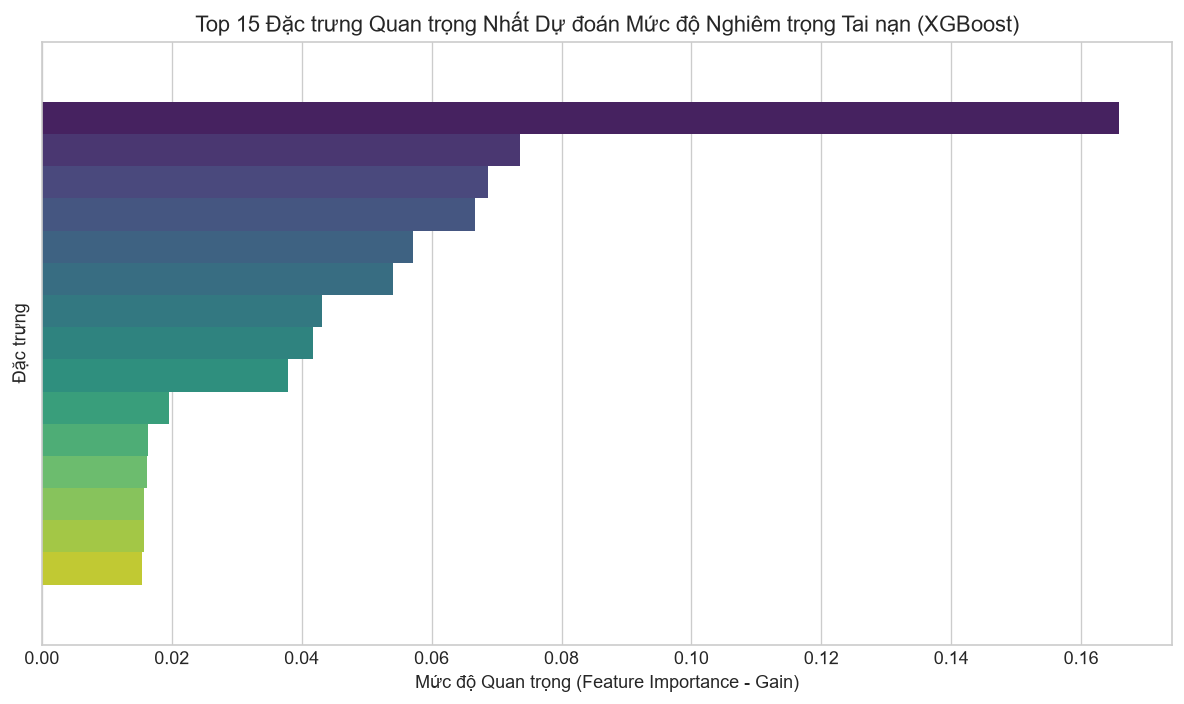

Top 10 Đặc trưng hàng đầu:
 Feature  Importance
State_FL    0.165758
State_IL    0.073611
State_WA    0.068743
State_MN    0.066710
State_CA    0.057206
State_OH    0.054012
State_GA    0.043064
State_SC    0.041776
Crossing    0.037829
State_WI    0.019575


In [7]:
# Trích xuất Feature Importance từ XGBoost
xgb_importance = advanced_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': xgb_importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_imp_df.head(15),
    x='Importance',
    hue='Feature',
    legend=False,
    palette='viridis'
)
plt.title('Top 15 Đặc trưng Quan trọng Nhất Dự đoán Mức độ Nghiêm trọng Tai nạn (XGBoost)')
plt.xlabel('Mức độ Quan trọng (Feature Importance - Gain)')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()

print("Top 10 Đặc trưng hàng đầu:")
print(feat_imp_df.head(10).to_string(index=False))


## 8. Phân tích SHAP Values & Permutation Importance


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16948\2673671461.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=all_feature_names, show=False)


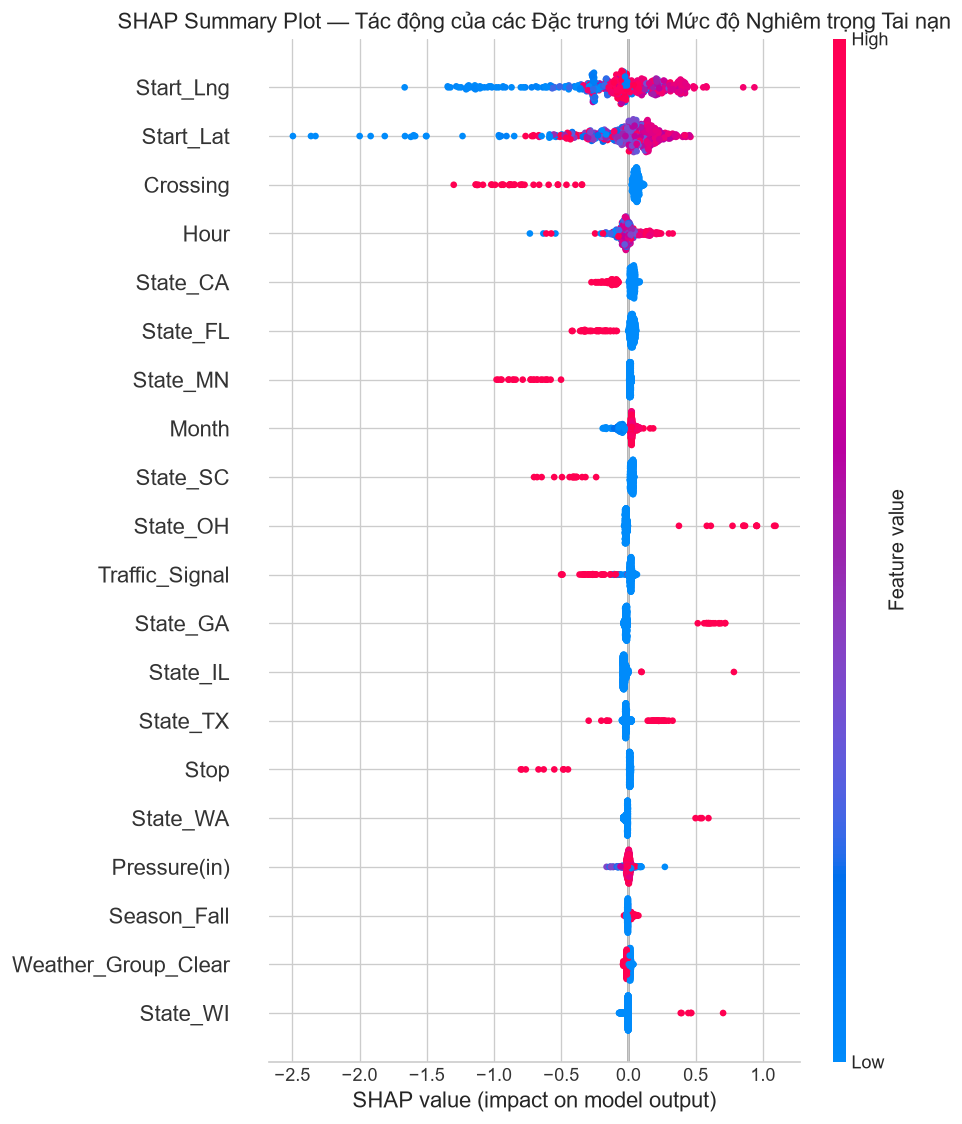

Đã tạo biểu đồ SHAP Summary Plot thành công!


In [9]:
# Kiểm tra và tính toán SHAP Values (hoặc Permutation Importance fallback)
has_shap = False
try:
    import shap
    explainer = shap.TreeExplainer(advanced_model)
    # Lấy mẫu 500 dòng test để tính toán nhanh SHAP values
    sample_indices = np.random.choice(X_test_proc.shape[0], min(500, X_test_proc.shape[0]), replace=False)
    X_sample = X_test_proc[sample_indices]
    
    shap_values = explainer(X_sample)
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_sample, feature_names=all_feature_names, show=False)
    plt.title('SHAP Summary Plot — Tác động của các Đặc trưng tới Mức độ Nghiêm trọng Tai nạn')
    plt.tight_layout()
    plt.show()
    has_shap = True
    print("Đã tạo biểu đồ SHAP Summary Plot thành công!")
except Exception as e:
    print(f"[THÔNG BÁO] Không thể khởi tạo SHAP ({e}). Tiến hành sử dụng Permutation Importance nâng cao...")

if not has_shap:
    # Tính Permutation Importance
    result = permutation_importance(
        advanced_model, X_test_proc, y_test,
        n_repeats=10, random_state=RANDOM_SEED, scoring='roc_auc'
    )
    
    perm_imp_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance_Mean': result.importances_mean,
        'Importance_Std': result.importances_std
    }).sort_values('Importance_Mean', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=perm_imp_df.head(15),
        x='Importance_Mean',
        hue='Feature',
        palette='magma'
    )
    plt.title('Top 15 Đặc trưng Quan trọng theo Permutation Importance (ROC-AUC Impact)')
    plt.xlabel('Mức giảm ROC-AUC trung bình')
    plt.ylabel('Đặc trưng')
    plt.tight_layout()
    plt.show()
    
    print("Top 10 Permutation Importances:")
    print(perm_imp_df.head(10).to_string(index=False))


## 9. Xuất Kết quả & Artifacts cho Báo cáo Nhóm


In [10]:
# Xuất file kết quả đánh giá mô hình
metrics_output_path = DATA_DIR / "model_metrics.csv"
feat_imp_output_path = DATA_DIR / "feature_importance.csv"

metrics_df.to_csv(metrics_output_path, index=False, encoding='utf-8-sig')
feat_imp_df.to_csv(feat_imp_output_path, index=False, encoding='utf-8-sig')

print("=" * 70)
print("XUẤT KẾT QUẢ THÀNH CÔNG!")
print("=" * 70)
print(f"  [OK] Metrics file            : {metrics_output_path}")
print(f"  [OK] Feature Importance file : {feat_imp_output_path}")
print("=" * 70)
print("Sẵn sàng cung cấp số liệu cho Thành viên 1 (Prescriptive Analysis) và Thành viên 5 (Slide Presentation).")


XUẤT KẾT QUẢ THÀNH CÔNG!
  [OK] Metrics file            : D:\Jo\Hk1_2026-2027\Data Analysis and Visualization\Term\data-analysis-us-accidents-project\data\model_metrics.csv
  [OK] Feature Importance file : D:\Jo\Hk1_2026-2027\Data Analysis and Visualization\Term\data-analysis-us-accidents-project\data\feature_importance.csv
Sẵn sàng cung cấp số liệu cho Thành viên 1 (Prescriptive Analysis) và Thành viên 5 (Slide Presentation).
